# TAE-IA

# **Inspector de Dispositivos Médicos — SATDM**
## Módulo de visión y voz para el Sistema Auditable de Trazabilidad de Dispositivos Médicos

**Objetivo:** adaptar el pipeline de *L12 — Inspector de Dispositivos* (visión + voz, manos-libres) a un caso de uso real
del **SATDM** (Sistema Auditable de Trazabilidad de Dispositivos Médicos para la Mejora de la Seguridad del Paciente
en la Red de Salud Pública de Nayarit): un técnico o enfermero toma una foto de un dispositivo médico (bomba de
infusión, ventilador, monitor, etc.), opcionalmente graba una nota de voz, y el sistema:

1. **Valida** que la imagen corresponda efectivamente a un dispositivo médico (*gatekeeper*), rechazando fotos ajenas al dominio.
2. **Identifica el tipo de dispositivo** mediante clasificación zero-shot (BiomedCLIP).
3. **Evalúa su estado físico/de seguridad** (funcional, dañado, etiqueta ilegible, corrosión, etc.), también zero-shot.
4. **Genera un reporte** (texto y, si hay voz de referencia, narrado con XTTS-v2) que incorpora la nota verbal del operador.
5. **Registra la inspección** en una bitácora auditable append-only (CSV con timestamp, ID de dispositivo y hash de la
   imagen), que es el artefacto de trazabilidad que alimenta al SATDM.

> Este notebook reutiliza y extiende directamente los cuatro modelos de L12 (**YOLOv8n**, **Whisper Small**,
> **BLIP-large**, **XTTS-v2**), y le agrega una quinta pieza —**BiomedCLIP**— como motor de clasificación clínica
> zero-shot, más una capa de bitácora auditable.

# **Módulos del Sistema**

| Módulo | Acción que realiza | Objetivo |
| :--- | :--- | :--- |
| **1. Setup** | Instala/actualiza librerías, monta Google Drive, configura GPU, directorios y semillas aleatorias | Preparar el entorno de ejecución |
| **2. Entradas** | Sube fotos de dispositivos y una voz de referencia | Tener datos para probar el pipeline |
| **3. Modelos** | Carga YOLOv8n, BiomedCLIP, BLIP-large, Whisper Small y XTTS-v2 | Disponer de las cinco piezas del sistema |
| **4. Contrato + Gatekeeper** | Define wrappers robustos y la validación de dominio médico | Evitar clasificar imágenes que no son dispositivos médicos |
| **5. Bitácora SATDM** | Define el registro auditable append-only | Dejar trazabilidad de cada inspección |
| **6. Pipeline** | Une gatekeeper + clasificación de tipo/estado + voz + bitácora | Producir un reporte completo por inspección |
| **7. Pruebas** | Corre entradas hostiles y una inspección real antes de exponer la app | Verificar que nada truene |
| **8. App (Gradio)** | Interfaz manos-libres con bitácora visible | Uso en campo por el personal de salud |

## 1 — Setup

In [1]:
!pip install --upgrade transformers huggingface-hub diffusers gradio
!pip install "transformers<5.0.0,>=4.40.0" "huggingface-hub<1.0,>=0.34.0"
!pip install coqui_tts
!pip install ultralytics
!pip install open_clip_torch


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 795.8/795.8 kB 30.1 MB/s eta 0:00:00
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface_hub 1.28.0
    Uninstalling huggingface_hub-1.28.0:
      Successfully uninstalled huggingface_hub-1.28.0
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 54.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 20.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 56.9 MB/s eta 0:00:00
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface_hub 1.29.0
    Uninstalling huggingface_hub-1.29.0:
      Successfully uninstalled huggingface_hub-1.29.0
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.23.1
    Uninstalling tokenizers-0.23.1:
      Successfully uninstalled tokenizers-0.23.1
  Attempting uninstall: transformers
    Found ex

In [2]:
import os, time, random, hashlib, io, csv
from datetime import datetime, timezone
import numpy as np
import pandas as pd
import torch
from PIL import Image
from TTS.api import TTS



from google.colab import drive
drive.mount('/content/drive')

DRIVE_ROOT = '/content/drive/MyDrive/TAE_IA_M6'
OUTPUT_DIR = f'{DRIVE_ROOT}/L12_output'
INPUT_DIR  = f'{DRIVE_ROOT}/inputs'
LEDGER_DIR = f'{DRIVE_ROOT}/SATDM_ledger'
LEDGER_PATH = f'{LEDGER_DIR}/inspecciones_log.csv'
for d in (OUTPUT_DIR, INPUT_DIR, LEDGER_DIR):
    os.makedirs(d, exist_ok=True)

MODEL_CACHE = '/content/models'
os.makedirs(MODEL_CACHE, exist_ok=True)
os.environ['HF_HOME']         = MODEL_CACHE
os.environ['TORCH_HOME']      = MODEL_CACHE
os.environ['YOLO_CONFIG_DIR'] = MODEL_CACHE
os.environ['TTS_HOME']        = MODEL_CACHE

if not torch.cuda.is_available():
    raise SystemExit('No GPU. Runtime > Change runtime type > T4 GPU')

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

def vram(tag=''):
    used  = torch.cuda.memory_allocated() / 1e9
    total = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f'  VRAM {used:5.2f} / {total:.1f} GB   {tag}')

print(torch.cuda.get_device_name(0)); vram('empty')
print("TTS cargado correctamente")
print(f"Bitácora SATDM en: {LEDGER_PATH}")


Mounted at /content/drive
Tesla T4
  VRAM  0.00 / 15.6 GB   empty
TTS cargado correctamente
Bitácora SATDM en: /content/drive/MyDrive/TAE_IA_M6/SATDM_ledger/inspecciones_log.csv


## 2 — Cargar imágenes de dispositivos y tu voz de referencia

In [3]:
IMG_EXTS = ('.jpg', '.jpeg', '.png', '.webp', '.bmp')
REFERENCE_VOICE = os.path.join(INPUT_DIR, 'reference_voice.wav')

def upload_inputs():
    from google.colab import files
    for name, data in files.upload().items():
        with open(os.path.join(INPUT_DIR, name), 'wb') as f:
            f.write(data)
        print('saved', name)

def load_inputs(n=5):
    names = [f for f in sorted(os.listdir(INPUT_DIR))
             if f.lower().endswith(IMG_EXTS)][:n]
    if not names:
        raise SystemExit(f'No images in {INPUT_DIR}. Run upload_inputs() first.')
    return {f: Image.open(os.path.join(INPUT_DIR, f)).convert('RGB') for f in names}

upload_inputs()          # <- corre una vez: sube fotos de dispositivos médicos + reference_voice.wav
print(f'{len(load_inputs())} images ready in {INPUT_DIR}')
print('reference voice found:', os.path.exists(REFERENCE_VOICE))


Saving agency-young-adult-profession-stressed-black.jpg to agency-young-adult-profession-stressed-black.jpg
Saving alex-knight-j4uuKnN43_M-unsplash.jpg to alex-knight-j4uuKnN43_M-unsplash.jpg
Saving angry-young-businessman-looking-laptop-office-background.jpg to angry-young-businessman-looking-laptop-office-background.jpg
Saving equipo medico.wav to equipo medico.wav
Saving photo-wall-texture-pattern.jpg to photo-wall-texture-pattern.jpg
Saving —Pngtree—work table with laptop and_6980923.png to —Pngtree—work table with laptop and_6980923.png
Saving pngwing_E_medico.com.png to pngwing_E_medico.com.png
Saving reference_voice.wav to reference_voice.wav
saved agency-young-adult-profession-stressed-black.jpg
saved alex-knight-j4uuKnN43_M-unsplash.jpg
saved angry-young-businessman-looking-laptop-office-background.jpg
saved equipo medico.wav
saved photo-wall-texture-pattern.jpg
saved —Pngtree—work table with laptop and_6980923.png
saved pngwing_E_medico.com.png
saved reference_voice.wav
5 ima

## 3 — Cargar los 5 modelos (YOLOv8n, BiomedCLIP, BLIP-large, Whisper, XTTS-v2)

In [4]:
import os
os.environ["COQUI_TOS_AGREED"] = "1"

import torch
import open_clip
from ultralytics import YOLO
from transformers import (BlipProcessor, BlipForConditionalGeneration,
                          WhisperProcessor, WhisperForConditionalGeneration)
from TTS.api import TTS


# 1. Cargar YOLO (localizador genérico de objetos, para recortar la región de interés)
yolo = YOLO('yolov8n.pt')                                                    # 6 MB
print(f'YOLO: {len(yolo.names)} COCO classes')


# 2. Cargar BiomedCLIP (clasificación zero-shot clínica: tipo de dispositivo + estado)
biomed_model, _, biomed_preprocess = open_clip.create_model_and_transforms(
    'hf-hub:microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224')
biomed_tokenizer = open_clip.get_tokenizer('hf-hub:microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224')
biomed_model = biomed_model.to('cuda').eval()
vram('after BiomedCLIP')


# 3. Cargar BLIP (descripción visual = insumo del gatekeeper y del reporte)
blip_proc = BlipProcessor.from_pretrained('Salesforce/blip-image-captioning-large')
blip_model = BlipForConditionalGeneration.from_pretrained(
    'Salesforce/blip-image-captioning-large', dtype=torch.float16).to('cuda').eval()
vram('after BLIP')


# 4. Cargar Whisper (nota de voz del operador -> texto)
whisper_proc = WhisperProcessor.from_pretrained('openai/whisper-small')
whisper_model = WhisperForConditionalGeneration.from_pretrained(
    'openai/whisper-small', dtype=torch.float16).to('cuda').eval()
vram('after Whisper')


# 5. Cargar Coqui TTS (XTTS v2, reporte narrado con la voz clonada del operador)
tts = TTS('tts_models/multilingual/multi-dataset/xtts_v2').to('cuda')        # descarga ~2 GB
vram('all five resident')


Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/content/models/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.
YOLO: 80 COCO classes


open_clip_config.json:   0%|          | 0.00/707 [00:00<?, ?B/s]

open_clip_pytorch_model.bin:   0%|          | 0.00/784M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/28.0 [00:00<?, ?B/s]

...

model.safetensors:   0%|          | 0.00/967M [00:00<?, ?B/s]

generation_config.json: 0.00B [00:00, ?B/s]

  VRAM  2.20 / 15.6 GB   after Whisper


100%|██████████| 1.87G/1.87G [00:38<00:00, 48.8MiB/s]
4.37kiB [00:00, 5.45MiB/s]
361kiB [00:00, 82.7MiB/s]
100%|██████████| 32.0/32.0 [00:00<00:00, 98.0kiB/s]
100%|██████████| 7.75M/7.75M [00:00<00:00, 11.4MiB/s]


  VRAM  4.11 / 15.6 GB   all five resident


## 4 — El contrato de entrada, los wrappers, y el gatekeeper médico

In [5]:
MAX_SIDE, MIN_SIDE = 1024, 32
ENTROPY_THRESHOLD = 0.85

def coerce_image(x):
    '''Cualquier cosa que entregue el usuario -> PIL RGB, o ValueError legible.'''
    if x is None:
        raise ValueError('No image received. Please upload one.')
    if isinstance(x, np.ndarray):
        x = Image.fromarray(x.astype(np.uint8))
    if not isinstance(x, Image.Image):
        raise ValueError('Unsupported input. Please upload an image file.')
    x = x.convert('RGB')
    w, h = x.size
    if min(w, h) < MIN_SIDE:
        raise ValueError(f'Image too small ({w}x{h}). Use at least {MIN_SIDE}x{MIN_SIDE}.')
    if max(w, h) > MAX_SIDE:
        s = MAX_SIDE / max(w, h)
        x = x.resize((int(w * s), int(h * s)), Image.LANCZOS)
    return x

def detect(img, conf=0.25):
    '''PIL -> [(label, confidence, (x1,y1,x2,y2))], la más fuerte primero.'''
    res = yolo(np.array(img), verbose=False)
    out = [(res[0].names[int(b.cls)], float(b.conf), tuple(map(int, b.xyxy[0])))
           for b in res[0].boxes if float(b.conf) >= conf]
    return sorted(out, key=lambda b: -b[1])

def caption(img, max_new_tokens=40):
    '''PIL -> str.'''
    inp = blip_proc(images=img.convert('RGB'), return_tensors='pt').to('cuda', torch.float16)
    with torch.no_grad():
        out = blip_model.generate(**inp, max_new_tokens=max_new_tokens, num_beams=3)
    return blip_proc.decode(out[0], skip_special_tokens=True).strip()

def transcribe(audio_path, language='es'):
    '''Ruta de audio -> texto. None/vacío -> '' (la nota de voz es opcional, no un error).'''
    if not audio_path:
        return ''
    import librosa
    speech, _ = librosa.load(audio_path, sr=16000)
    feats = whisper_proc(speech, sampling_rate=16000, return_tensors='pt').input_features
    feats = feats.to('cuda', torch.float16)
    forced_ids = whisper_proc.get_decoder_prompt_ids(language=language, task='transcribe')
    with torch.no_grad():
        ids = whisper_model.generate(feats, forced_decoder_ids=forced_ids)
    return whisper_proc.batch_decode(ids, skip_special_tokens=True)[0].strip()

def synthesize(text, speaker_wav, out_path, language='es'):
    '''Texto + ~10s de audio de referencia -> .wav narrado. XTTS-v2 clona esa voz.'''
    tts.tts_to_file(text=text, speaker_wav=speaker_wav, language=language, file_path=out_path)
    return out_path


# --------------------------------------------------
# GATEKEEPER: ¿la imagen es plausiblemente un dispositivo médico?
# --------------------------------------------------
GATEKEEPER_KEYWORDS = ['medical', 'device', 'equipment', 'machine', 'monitor', 'hospital',
                        'clinical', 'apparatus', 'instrument', 'cable', 'screen', 'tube',
                        'pump', 'ventilator', 'oxygen', 'wheelchair', 'bed', 'tank', 'panel']
GATEKEEPER_FORBIDDEN = ['person', 'face', 'man', 'woman', 'child', 'animal', 'dog', 'cat',
                         'food', 'plant', 'flower', 'landscape', 'mountain', 'street', 'car',
                         'building exterior', 'forest']

def gatekeeper_pass(caption_text):
    '''str -> (bool pasó, str razón). Basado en la descripción de BLIP, igual que el gatekeeper
    del clasificador zero-shot validado, pero adaptado a un solo dominio: dispositivos médicos.'''
    caption_low = caption_text.lower()
    forbidden_found = [w for w in GATEKEEPER_FORBIDDEN if w in caption_low]
    keyword_found = [w for w in GATEKEEPER_KEYWORDS if w in caption_low]
    passed = (not forbidden_found) and (len(keyword_found) > 0)
    if forbidden_found:
        reason = f'Contenido fuera de dominio detectado: {", ".join(forbidden_found)}'
    elif not keyword_found:
        reason = 'La descripción visual no sugiere un dispositivo médico'
    else:
        reason = ''
    return passed, reason


# --------------------------------------------------
# CLASIFICACIÓN ZERO-SHOT CON BIOMEDCLIP: tipo de dispositivo y estado
# --------------------------------------------------
DEVICE_TYPE_TEMPLATES = {
    'bomba de infusión': [
        'a medical infusion pump device',
        'a hospital IV infusion pump with tubing',
        'a clinical infusion pump on a metal stand',
    ],
    'monitor de signos vitales': [
        'a patient vital signs monitor with a screen',
        'a hospital bedside monitor showing heart rate',
        'a clinical multiparameter monitor',
    ],
    'ventilador mecánico': [
        'a mechanical ventilator machine for breathing support',
        'a hospital ventilator with tubes and display',
        'an ICU ventilator device',
    ],
    'desfibrilador': [
        'a medical defibrillator device with paddles',
        'a hospital defibrillator machine',
        'an automated external defibrillator',
    ],
    'electrocardiógrafo': [
        'an electrocardiograph ECG machine with leads',
        'a hospital ECG device with cables',
        'a clinical electrocardiogram machine',
    ],
    'oxímetro de pulso': [
        'a pulse oximeter clip device',
        'a small medical oxygen saturation monitor',
        'a fingertip pulse oximeter',
    ],
    'silla de ruedas': [
        'a hospital wheelchair for patient mobility',
        'a medical wheelchair with wheels and handles',
        'a clinical transport wheelchair',
    ],
    'cama de hospital': [
        'a hospital bed with rails and controls',
        'a clinical adjustable hospital bed',
        'a medical patient bed',
    ],
    'esterilizador / autoclave': [
        'a medical autoclave sterilizer machine',
        'a hospital sterilization equipment',
        'a clinical steam sterilizer device',
    ],
    'tanque de oxígeno': [
        'a medical oxygen tank cylinder',
        'a hospital oxygen supply tank with a gauge',
        'a clinical oxygen cylinder on a cart',
    ],
}

STATUS_TEMPLATES = {
    'funcional / buen estado': [
        'a medical device in good working condition',
        'a clean and functional hospital equipment',
        'a well maintained clinical device',
    ],
    'dañado / daño visible': [
        'a medical device with visible physical damage',
        'a broken or cracked hospital equipment',
        'a clinical device with a damaged casing',
    ],
    'etiqueta o número de serie ilegible': [
        'a medical device with a faded or illegible label',
        'hospital equipment with an unreadable serial number tag',
        'a clinical device missing identification markings',
    ],
    'sucio o contaminado visible': [
        'a medical device that looks dirty or stained',
        'hospital equipment with visible dirt or residue',
        'a clinical device with contamination on its surface',
    ],
    'corrosión u oxidación visible': [
        'a medical device with visible rust or corrosion',
        'hospital equipment with oxidized metal parts',
        'a clinical device showing corrosion damage',
    ],
    'cables o componentes expuestos': [
        'a medical device with exposed wires or cables',
        'hospital equipment with loose or exposed components',
        'a clinical device with an open panel and visible wiring',
    ],
}

DAMAGE_INDICATORS = ['broken', 'crack', 'rust', 'dirty', 'exposed', 'damaged', 'wire',
                      'torn', 'dust', 'stain', 'corrosion', 'faded', 'unreadable']

def clip_zero_shot(image, templates_dict):
    '''PIL + {label: [prompts]} -> (probs por prompt, mapeo prompt->label).'''
    text_queries, label_mapping = [], []
    for label, prompts in templates_dict.items():
        for p in prompts:
            text_queries.append(p)
            label_mapping.append(label)
    img_in = biomed_preprocess(image).unsqueeze(0).to('cuda')
    txt_in = biomed_tokenizer(text_queries).to('cuda')
    with torch.no_grad():
        image_features = biomed_model.encode_image(img_in)
        text_features = biomed_model.encode_text(txt_in)
        image_features = image_features / image_features.norm(dim=-1, keepdim=True)
        text_features = text_features / text_features.norm(dim=-1, keepdim=True)
        logits = (100.0 * image_features @ text_features.T).softmax(dim=-1)
    return logits.cpu().numpy()[0], label_mapping

def aggregate_by_label(probs, label_mapping, labels):
    '''Promedia las probabilidades de todos los prompts de cada etiqueta y renormaliza.'''
    agg = {l: 0.0 for l in labels}
    for p, l in zip(probs, label_mapping):
        agg[l] += p
    total = sum(agg.values()) or 1.0
    return {l: v / total for l, v in agg.items()}

def best_label(agg):
    '''{label: prob} -> (mejor etiqueta, confianza, entropía normalizada [0,1]).'''
    label = max(agg, key=agg.get)
    conf = agg[label]
    entropy = -sum(v * np.log2(v + 1e-10) for v in agg.values())
    norm_entropy = entropy / np.log2(len(agg))
    return label, conf, norm_entropy

def sha256_of_image(img):
    '''PIL -> hash SHA-256 del contenido de píxeles (identidad de la evidencia fotográfica).'''
    buf = io.BytesIO()
    img.save(buf, format='PNG')
    return hashlib.sha256(buf.getvalue()).hexdigest()


## 5 — Bitácora auditable SATDM (registro append-only)

In [6]:
LEDGER_FIELDS = ['timestamp_utc', 'device_id', 'image_filename', 'image_sha256',
                 'gatekeeper_passed', 'gatekeeper_reason',
                 'tipo_detectado', 'tipo_confianza', 'tipo_entropia',
                 'estado_detectado', 'estado_confianza', 'estado_entropia',
                 'reporte_texto', 'audio_reporte_path']

def log_inspection(record):
    '''dict -> escribe una fila en LEDGER_PATH (crea encabezado si el archivo no existe).
    Append-only: nunca se sobreescriben ni borran filas anteriores.'''
    file_exists = os.path.exists(LEDGER_PATH)
    with open(LEDGER_PATH, 'a', newline='', encoding='utf-8') as f:
        writer = csv.DictWriter(f, fieldnames=LEDGER_FIELDS)
        if not file_exists:
            writer.writeheader()
        writer.writerow(record)
    return LEDGER_PATH

def read_ledger_tail(n=10):
    if not os.path.exists(LEDGER_PATH):
        return pd.DataFrame(columns=LEDGER_FIELDS)
    return pd.read_csv(LEDGER_PATH).tail(n)

print('Bitácora lista en', LEDGER_PATH)


Bitácora lista en /content/drive/MyDrive/TAE_IA_M6/SATDM_ledger/inspecciones_log.csv


## 6 — El pipeline SATDM

In [7]:
def run_inspection(img, audio_note=None, device_id='', conf=0.25, language='es',
                    image_filename='captura.jpg'):
    '''Nunca truena. Devuelve (region, ruta_audio_o_None, texto_reporte, registro_bitacora_o_None).'''
    try:
        img = coerce_image(img)
    except ValueError as e:
        return None, None, str(e), None

    try:
        dets = detect(img, conf)
        if dets:
            label, _, (x1, y1, x2, y2) = dets[0]
            w, h = img.size
            region = img.crop((max(0, x1 - 20), max(0, y1 - 20),
                               min(w, x2 + 20), min(h, y2 + 20)))
        else:
            region = img

        visual_caption = caption(region)
        gk_pass, gk_reason = gatekeeper_pass(visual_caption)
        img_hash = sha256_of_image(img)
        timestamp = datetime.now(timezone.utc).isoformat()

        if not gk_pass:
            report_text = (f'❌ Imagen rechazada por el gatekeeper del SATDM. {gk_reason}. '
                            f'Descripción visual: {visual_caption}.')
            record = {
                'timestamp_utc': timestamp, 'device_id': device_id or 'N/D',
                'image_filename': image_filename, 'image_sha256': img_hash,
                'gatekeeper_passed': False, 'gatekeeper_reason': gk_reason,
                'tipo_detectado': '', 'tipo_confianza': '', 'tipo_entropia': '',
                'estado_detectado': '', 'estado_confianza': '', 'estado_entropia': '',
                'reporte_texto': report_text, 'audio_reporte_path': '',
            }
            log_inspection(record)
            return region, None, report_text, record

        # 1) Tipo de dispositivo
        type_probs, type_map = clip_zero_shot(region, DEVICE_TYPE_TEMPLATES)
        type_agg = aggregate_by_label(type_probs, type_map, list(DEVICE_TYPE_TEMPLATES.keys()))
        tipo, tipo_conf, tipo_entropy = best_label(type_agg)

        # 2) Estado físico/de seguridad, calibrado si el caption menciona indicios de daño
        status_probs, status_map = clip_zero_shot(region, STATUS_TEMPLATES)
        status_agg = aggregate_by_label(status_probs, status_map, list(STATUS_TEMPLATES.keys()))
        caption_low = visual_caption.lower()
        if any(w in caption_low for w in DAMAGE_INDICATORS):
            healthy_key = 'funcional / buen estado'
            if healthy_key in status_agg:
                status_agg[healthy_key] *= 0.1
                total = sum(status_agg.values()) or 1.0
                status_agg = {k: v / total for k, v in status_agg.items()}
        estado, estado_conf, estado_entropy = best_label(status_agg)

        voice_text = transcribe(audio_note, language=language) if audio_note else ''

        report_text = (f'Dispositivo: {tipo} (confianza {tipo_conf:.0%}). '
                        f'Estado: {estado} (confianza {estado_conf:.0%}). '
                        f'{visual_caption}.')
        if voice_text:
            report_text += f' Nota del operador: {voice_text}'
        if tipo_entropy > ENTROPY_THRESHOLD or estado_entropy > ENTROPY_THRESHOLD:
            report_text += ' ⚠️ Clasificación ambigua — se recomienda revisión manual.'

        speaker_ref = audio_note if audio_note else REFERENCE_VOICE
        audio_path = None
        if os.path.exists(speaker_ref):
            audio_path = os.path.join(OUTPUT_DIR, f'reporte_{int(time.time())}.wav')
            synthesize(report_text, speaker_ref, audio_path, language=language)
        else:
            report_text += '\n[sin audio de referencia - sube reference_voice.wav o graba una nota de voz]'

        record = {
            'timestamp_utc': timestamp, 'device_id': device_id or 'N/D',
            'image_filename': image_filename, 'image_sha256': img_hash,
            'gatekeeper_passed': True, 'gatekeeper_reason': '',
            'tipo_detectado': tipo, 'tipo_confianza': f'{tipo_conf:.4f}', 'tipo_entropia': f'{tipo_entropy:.4f}',
            'estado_detectado': estado, 'estado_confianza': f'{estado_conf:.4f}', 'estado_entropia': f'{estado_entropy:.4f}',
            'reporte_texto': report_text, 'audio_reporte_path': audio_path or '',
        }
        log_inspection(record)

    except torch.cuda.OutOfMemoryError:
        torch.cuda.empty_cache()
        return None, None, 'Se agotó la memoria de la GPU. Intenta con una imagen más pequeña.', None
    except Exception as e:
        print(f'[run_inspection] {type(e).__name__}: {e}')
        return None, None, 'Algo salió mal. Intenta con otra imagen o nota.', None

    return region, audio_path, report_text, record


## 7 — Pruébalo antes de que lo vea alguien más

In [8]:
imgs = load_inputs()
print(f'--- detección genérica (YOLO/COCO) en {len(imgs)} imágenes ---')
for name, im in imgs.items():
    dets = detect(im)
    print(f'{name[:18]:18s} -> ' + (', '.join(f'{l} {c:.2f}' for l, c, _ in dets[:4])
                                    or '*** sin caja COCO (se usará la imagen completa) ***'))

ref = next(iter(imgs.values()))
print('\n--- entradas hostiles: ninguna debe tronar ---')
for tag, bad in [('None', None),
                 ('numpy', np.zeros((64, 64, 3), dtype=np.uint8)),
                 ('grayscale', ref.convert('L')),
                 ('RGBA', ref.convert('RGBA')),
                 ('1x1', Image.new('RGB', (1, 1))),
                 ('12 MP', Image.new('RGB', (4000, 3000), 'white'))]:
    _r, _a, msg, _rec = run_inspection(bad, device_id='TEST-000')
    print(f'  {tag:10s} -> {msg.splitlines()[0][:70]}')

print('\n--- corrida real: primera imagen de la carpeta de inputs ---')
first_name = next(iter(imgs))
region, audio_path, report, record = run_inspection(
    imgs[first_name], device_id='NAY-HGZ1-BINF-001', image_filename=first_name)
print(report)
if audio_path:
    print('audio guardado ->', audio_path)
vram('peak')

print('\n--- últimas filas de la bitácora SATDM ---')
print(read_ledger_tail())


--- detección genérica (YOLO/COCO) en 5 imágenes ---
agency-young-adult -> laptop 0.85, person 0.82, person 0.70
agency-young-adult -> laptop 0.85, person 0.82, person 0.70
agency-young-adult -> laptop 0.85, person 0.82, person 0.70
agency-young-adult -> laptop 0.85, person 0.82, person 0.70
agency-young-adult -> laptop 0.85, person 0.82, person 0.70

--- entradas hostiles: ninguna debe tronar ---
  None       -> No image received. Please upload one.
  numpy      -> ❌ Imagen rechazada por el gatekeeper del SATDM. Contenido fuera de dom
  grayscale  -> ❌ Imagen rechazada por el gatekeeper del SATDM. Contenido fuera de dom
  RGBA       -> ❌ Imagen rechazada por el gatekeeper del SATDM. Contenido fuera de dom
  1x1        -> Image too small (1x1). Use at least 32x32.
  12 MP      -> ❌ Imagen rechazada por el gatekeeper del SATDM. Contenido fuera de dom

--- corrida real: primera imagen de la carpeta de inputs ---
❌ Imagen rechazada por el gatekeeper del SATDM. Contenido fuera de dominio d

## 8 — La app (Gradio) — uso en campo, manos-libres

In [9]:
import gradio as gr

def predict(image, audio_note, device_id, conf, progress=gr.Progress()):
    if image is None:
        return None, None, 'Por favor sube una foto del dispositivo.', read_ledger_tail()
    progress(0.2, desc='Verificando dominio (gatekeeper)...')
    progress(0.5, desc='Clasificando tipo y estado (BiomedCLIP)...')
    region, audio_path, report, record = run_inspection(
        image, audio_note=audio_note, device_id=device_id, conf=conf)
    progress(0.9, desc='Actualizando bitácora SATDM...')
    df = read_ledger_tail()
    progress(1.0, desc='Listo')
    return region, audio_path, report, df

with gr.Blocks(title='Inspector de Dispositivos Médicos — SATDM') as app:
    gr.Markdown('# Inspector de Dispositivos Médicos (SATDM)\n'
                'Sube una foto del dispositivo médico. Opcional: graba una nota de voz — el reporte '
                'se narra con tu propia voz clonada. Cada inspección queda en la bitácora auditable.')
    with gr.Row():
        with gr.Column():
            inp       = gr.Image(type='pil', label='Foto del dispositivo médico')
            audio_in  = gr.Audio(type='filepath', label='Nota de voz (opcional)')
            device_id = gr.Textbox(label='ID de dispositivo / activo (opcional)',
                                    placeholder='p.ej. NAY-HGZ1-BINF-001')
            conf      = gr.Slider(0.05, 0.7, value=0.25, step=0.05, label='Confianza de detección (YOLO)')
            with gr.Row():
                go    = gr.Button('Inspeccionar', variant='primary')
                clear = gr.Button('Limpiar')
        with gr.Column():
            out_region = gr.Image(label='Región analizada')
            out_audio  = gr.Audio(label='Reporte narrado')
            out_report = gr.Textbox(label='Reporte (texto)', lines=5)
    gr.Markdown('### Bitácora SATDM (últimos registros)')
    out_ledger = gr.Dataframe(value=read_ledger_tail(), interactive=False)

    go.click(predict, [inp, audio_in, device_id, conf], [out_region, out_audio, out_report, out_ledger])
    clear.click(lambda: (None, None, '', None, None, '', read_ledger_tail()), None,
                [inp, audio_in, device_id, out_region, out_audio, out_report, out_ledger])

app.queue().launch(share=True, quiet=True)


* Running on public URL: https://183bf25127b5a8e5ff.gradio.live


---

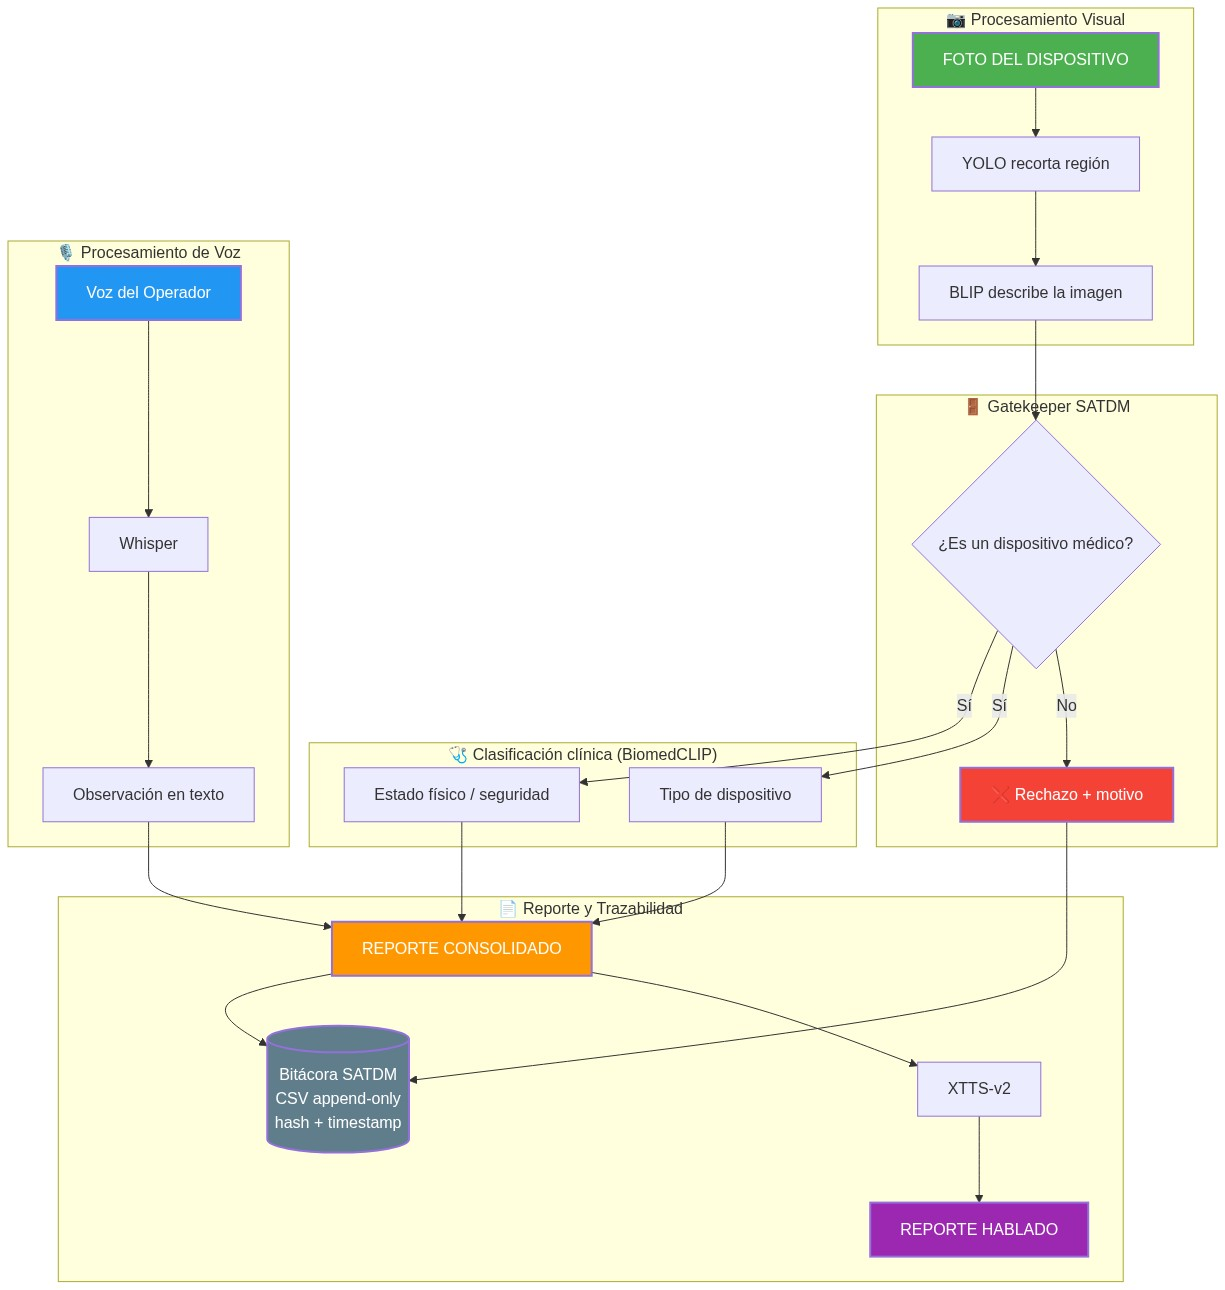

✅ Imagen guardada como 'diagrama_inspector_satdm.png'


In [10]:
import base64
import requests
from IPython.display import Image, display

def render_mermaid(graph_code: str):
    '''Renderiza un diagrama Mermaid como imagen PNG en Colab.'''
    graphBYTES = graph_code.encode("utf-8")
    base64BYTES = base64.urlsafe_b64encode(graphBYTES)
    base64STRING = base64BYTES.decode("utf-8")
    url = f"https://mermaid.ink/img/{base64STRING}"
    response = requests.get(url)
    if response.status_code == 200:
        display(Image(response.content))
        with open("diagrama_inspector_satdm.png", "wb") as f:
            f.write(response.content)
        print("✅ Imagen guardada como 'diagrama_inspector_satdm.png'")
    else:
        print("❌ Error al generar el diagrama.")

diagrama = '''
flowchart TD
    subgraph Entrada_Imagen["📷 Procesamiento Visual"]
        A[FOTO DEL DISPOSITIVO] --> B[YOLO recorta región]
        B --> C[BLIP describe la imagen]
    end

    subgraph Gate["🚪 Gatekeeper SATDM"]
        C --> D{"¿Es un dispositivo médico?"}
        D -- No --> R["❌ Rechazo + motivo"]
    end

    subgraph Clasificacion["🩺 Clasificación clínica (BiomedCLIP)"]
        D -- Sí --> E[Tipo de dispositivo]
        D -- Sí --> F[Estado físico / seguridad]
    end

    subgraph Entrada_Audio["🎙️ Procesamiento de Voz"]
        G[Voz del Operador] --> H[Whisper]
        H --> I[Observación en texto]
    end

    subgraph Salida["📄 Reporte y Trazabilidad"]
        E --> J[REPORTE CONSOLIDADO]
        F --> J
        I --> J
        J --> K[XTTS-v2]
        K --> L[REPORTE HABLADO]
        J --> M[("Bitácora SATDM\\nCSV append-only\\nhash + timestamp")]
        R --> M
    end

    style A fill:#4CAF50,color:#fff,stroke-width:2px
    style G fill:#2196F3,color:#fff,stroke-width:2px
    style J fill:#FF9800,color:#fff,stroke-width:2px
    style L fill:#9C27B0,color:#fff,stroke-width:2px
    style M fill:#607D8B,color:#fff,stroke-width:2px
    style R fill:#F44336,color:#fff,stroke-width:2px
'''

render_mermaid(diagrama)
